
# Tiny-GPT training from scratch on WikiText-2

In this assignment we will implement and train a small decoder-only Transformer language model from scratch on **WikiText-2** in **Google Colab**.


In [1]:
!pip -q install datasets transformers


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



## 1. Imports and environment setup

This section:
- disables tokenizer parallelism warnings in Google Colab,
- imports required libraries,
- selects the runtime device.


**Note:** Ensure that runtime is cuda otherwise training will be painfully slow.


In [2]:

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from datasets import load_dataset
from transformers import AutoTokenizer
import torch, math, glob, random
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

if device != "cuda":
  print("Training will be slow since CUDA is not available....")

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda



## 2. Optional Google Drive mount for checkpoints

In Colab, training may be interrupted by runtime resets or disconnects.  
This section mounts Google Drive and prepares a checkpoint directory so training can resume later.

If Drive is unavailable, the notebook falls back to a local path.


In [3]:

use_drive = False

if use_drive:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        base_dir = "/content/drive/MyDrive/gpt_wikitext2_solution"
    except Exception:
        base_dir = "/content/gpt_wikitext2_solution"
else:
    base_dir = "./content/gpt_wikitext2_solution"

os.makedirs(base_dir, exist_ok=True)
ckpt_dir = os.path.join(base_dir, "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)

print("base_dir:", base_dir)
print("checkpoint directory:", ckpt_dir)


base_dir: ./content/gpt_wikitext2_solution
checkpoint directory: ./content/gpt_wikitext2_solution\checkpoints



## 3. Load WikiText-2 from Hugging Face

We use the raw WikiText-2 split:

- dataset: `Salesforce/wikitext`
- config: `wikitext-2-raw-v1`

The raw version contains plain text rather than the processed word-level benchmark form, which makes it appropriate for custom tokenizer-based language modeling.


In [4]:

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
dataset


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [5]:

for split in dataset:
    print(split, len(dataset[split]))
print()
print("sample train rows:")
print(dataset["train"][0])
print(dataset["train"][1])


test 4358
train 36718
validation 3760

sample train rows:
{'text': ''}
{'text': ' = Valkyria Chronicles III = \n'}



## 4. Initialize the tokenizer

We use the GPT-2 tokenizer for convenience. If no pad token is defined, we reuse the EOS token as the pad token.


In [6]:

tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("vocab_size:", tokenizer.vocab_size)
print("eos_token_id:", tokenizer.eos_token_id)
print("pad_token_id:", tokenizer.pad_token_id)


vocab_size: 50257
eos_token_id: 50256
pad_token_id: 50256



## 5. Preprocess the text corpus

The preprocessing pipeline is:

1. remove empty or whitespace-only strings,
2. tokenize each text example,
3. append an EOS token after each example,
4. concatenate all token IDs into one flat stream.

This flat-stream setup is simple and effective for next-token prediction.


In [7]:
def clean(xs):
    return [x for x in xs if x and x.strip()]

train_text = clean(dataset["train"]["text"])
val_text = clean(dataset["validation"]["text"])

def encode(xs):
    ids = []
    for t in xs:
        tok = tokenizer.encode(t, add_special_tokens=False)
        tok.append(tokenizer.eos_token_id)
        ids.extend(tok)
    return ids

train_ids = encode(train_text)
val_ids = encode(val_text)

print("num train texts:", len(train_text))
print("num val texts:", len(val_text))
print()
print("num train tokens:", len(train_ids))
print("num val tokens:", len(val_ids))

num train texts: 23767
num val texts: 2461

num train tokens: 2415651
num val tokens: 249750



## 6. Build the next-token-prediction dataset

Each example consists of:
- an input sequence `x` of length `block_size`,
- a target sequence `y` of length `block_size`.

The target is the input shifted by one token:
- `x = ids[i : i + block_size]`
- `y = ids[i + 1 : i + block_size + 1]`


In [9]:
block_size = 128

class TokenDataset(Dataset):
    def __init__(self, ids, block):
        self.ids = torch.as_tensor(ids, dtype=torch.long)
        self.block = block
        self.x = self.ids[:-1].unfold(0, self.block, 1)
        self.y = self.ids[1:].unfold(0, self.block, 1)

    def __len__(self):
        return max(0, len(self.ids) - self.block)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

train_ds = TokenDataset(train_ids, block_size)
val_ds = TokenDataset(val_ids, block_size)

print("train examples:", len(train_ds))
print("val examples:", len(val_ds))

train examples: 2415523
val examples: 249622



## 7. Create dataloaders

For Colab stability:
- `num_workers=4`
- tokenizer parallelism disabled


In [13]:
batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

xb, yb = next(iter(train_loader))
xb = xb.to(device, non_blocking=True)
yb = yb.to(device, non_blocking=True)
print("train batch x shape:", xb.shape)
print("train batch y shape:", yb.shape)

train batch x shape: torch.Size([64, 128])
train batch y shape: torch.Size([64, 128])



## 8. Define model hyperparameters

These settings are intentionally small enough for Colab.


In [14]:

vocab_size = tokenizer.vocab_size
n_embd = 256
n_head = 4
n_layer = 4
dropout = 0.1
lr = 3e-4

assert n_embd % n_head == 0



## 9. Implement causal self-attention

This module performs:
- Q, K, V projection,
- multi-head reshape,
- scaled dot-product attention,
- causal masking,
- output projection.


In [15]:
class Attention(nn.Module):
    def __init__(self, d, h, block, dropout=0.1):
        super().__init__()
        assert d % h == 0
        self.h = h
        self.head_dim = d // h  # TODO: compute head dimension

        # TODO: define the four linear projections
        self.q_proj = nn.Linear(d, d)
        self.k_proj = nn.Linear(d, d)
        self.v_proj = nn.Linear(d, d)
        self.out_proj = nn.Linear(d, d)
        self.dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block, block))
        self.register_buffer("mask", mask.view(1, 1, block, block))

    def forward(self, x):
        B, T, C = x.shape

        # TODO: project inputs to q, k, v
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # TODO: reshape q, k, v into multi-head format
        q = q.view(B, T, self.h, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.h, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.h, self.head_dim).transpose(1, 2)

        # TODO: compute scaled dot-product attention scores
        att = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)

        # TODO: apply the causal mask
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))

        # TODO: normalize attention scores and apply dropout
        att = torch.softmax(att, dim=-1)
        att = self.dropout(att)

        # TODO: apply attention to the values
        y = att @ v

        # TODO: merge the heads back together
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # TODO: apply the final output projection
        y = self.out_proj(y)
        return y


## 10. Implement the feed-forward network

A standard Transformer MLP:
- expand from `d` to `4d`,
- apply GELU,
- project back to `d`,
- apply dropout.


In [17]:
class MLP(nn.Module):
    def __init__(self, d, dropout=0.1):
        super().__init__()
        # TODO: define the two linear layers and activation
        self.fc1 = nn.Linear(d, 4 * d)
        self.fc2 = nn.Linear(4 * d, d)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # TODO: implement the MLP forward pass
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


## 11. Implement one Transformer block

We use a pre-norm residual block layout:
- LayerNorm
- attention
- residual addition
- LayerNorm
- MLP
- residual addition


In [18]:
class Block(nn.Module):
    def __init__(self, d, h, block, dropout=0.1):
        super().__init__()
        # TODO: define the layer norms, attention module, and MLP
        self.ln1 = nn.LayerNorm(d)
        self.attn = Attention(d, h, block, dropout)
        self.ln2 = nn.LayerNorm(d)
        self.mlp = MLP(d, dropout)

    def forward(self, x):
        # TODO: implement the pre-norm residual block
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

## 12. Implement the full GPT model

The model includes:
- token embeddings,
- positional embeddings, which encode the order of tokens in a sequence, allowing the model to understand the position of each word. These are **learnable** positional embeddings.
- stacked Transformer blocks,
- final LayerNorm,
- language-model head.

The forward pass returns:
- `logits`
- `loss` if targets are provided

In [24]:
class GPT(nn.Module):
    def __init__(self, vocab, block, d=256, h=4, L=4, dropout=0.1):
        super().__init__()
        self.block = block

        # TODO: define token embedding, positional embedding, dropout,
        # Transformer blocks, final layer norm, and LM head
        self.token_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(block, d)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block(d, h, block, dropout) for _ in range(L)])
        self.ln_f = nn.LayerNorm(d)
        self.lm_head = nn.Linear(d, vocab, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.block:
            raise ValueError(f"sequence length {T} exceeds block size {self.block}")

        # TODO: create position indices
        pos = torch.arange(0, T, device=idx.device)

        # TODO: combine token and positional embeddings and apply dropout
        x = self.token_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)

        # TODO: pass x through all Transformer blocks
        x = self.blocks(x)

        # TODO: compute logits using the final layer norm and LM head
        logits = self.lm_head(self.ln_f(x))

        loss = None
        if targets is not None:
            # TODO: compute next-token cross-entropy loss
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss


## 13. Instantiate model and optimizer


In [25]:
# TODO: instantiate the GPT model and AdamW optimizer

model = GPT(vocab_size, block_size, n_embd, n_head, n_layer, dropout).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=lr)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable parameters:", f"{num_params:,}")

trainable parameters: 28,923,904



## 14. Checkpoint utilities

Each checkpoint stores:
- model weights,
- optimizer state,
- training step,
- loss step and history

This is enough to resume the training loop cleanly for this notebook.


In [26]:
def get_checkpoint_path(step):
    return os.path.join(ckpt_dir, f"ckpt_step_{step:06d}.pt")

def save_checkpoint(model, opt, step, loss_steps, loss_history):
    state = {
        "model": model.state_dict(),
        "optimizer": opt.state_dict(),
        "step": step,
        "loss_steps": loss_steps,
        "loss_history": loss_history,
    }
    path = get_checkpoint_path(step)
    torch.save(state, path)
    print("saved checkpoint:", path)

def latest_checkpoint():
    ckpts = sorted(glob.glob(os.path.join(ckpt_dir, "ckpt_step_*.pt")))
    return ckpts[-1] if ckpts else None

def load_checkpoint(path, model, opt):
    state = torch.load(path, map_location=device)
    model.load_state_dict(state["model"])
    opt.load_state_dict(state["optimizer"])
    start_step = state["step"]
    loss_steps = state.get("loss_steps", [])
    loss_history = state.get("loss_history", [])
    print("loaded checkpoint:", path, "| step:", start_step)
    return start_step, loss_steps, loss_history


## 15. Resume training if a checkpoint exists

If a checkpoint is found, training resumes from that step.
Otherwise, training starts from scratch.


In [27]:
start_step = 0
loss_steps = []
loss_history = []

last_ckpt = latest_checkpoint()

if last_ckpt is not None:
    start_step, loss_steps, loss_history = load_checkpoint(last_ckpt, model, opt)
else:
    print("no checkpoint found, starting from scratch")

no checkpoint found, starting from scratch



## 16. Training loop

This loop:
- runs forward pass,
- computes loss,
- backpropagates,
- clips gradients,
- updates parameters,
- saves checkpoints periodically.

The default step budget is modest so the notebook remains Colab-friendly.


In [28]:
max_steps = 1500
save_every = 200

model.train()
step = start_step

for epoch in range(1000):
    for x, y in train_loader:
        if step >= max_steps:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # TODO: run the forward pass
        logits, loss = model(x, y)

        # TODO: zero gradients
        opt.zero_grad()

        # TODO: backpropagate the loss
        loss.backward()

        # TODO: clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # TODO: take an optimizer step
        opt.step()

        # TODO: save the current step and loss for plotting
        loss_steps.append(step)
        loss_history.append(loss.item())

        if step % 50 == 0:
            print(f"step {step} | loss {loss.item():.4f}")

        if step > 0 and step % save_every == 0:
            save_checkpoint(model, opt, step, loss_steps, loss_history)

        step += 1

    if step >= max_steps:
        break

step 0 | loss 10.8620
step 50 | loss 7.4565
step 100 | loss 6.8252
step 150 | loss 6.6081
step 200 | loss 6.2890
saved checkpoint: ./content/gpt_wikitext2_solution\checkpoints\ckpt_step_000200.pt
step 250 | loss 6.1986
step 300 | loss 6.0068
step 350 | loss 6.0433
step 400 | loss 5.8358
saved checkpoint: ./content/gpt_wikitext2_solution\checkpoints\ckpt_step_000400.pt
step 450 | loss 5.6701
step 500 | loss 5.7068
step 550 | loss 5.6742
step 600 | loss 5.5586
saved checkpoint: ./content/gpt_wikitext2_solution\checkpoints\ckpt_step_000600.pt
step 650 | loss 5.4117
step 700 | loss 5.3851
step 750 | loss 5.2379
step 800 | loss 5.2133
saved checkpoint: ./content/gpt_wikitext2_solution\checkpoints\ckpt_step_000800.pt
step 850 | loss 5.2248
step 900 | loss 5.0000
step 950 | loss 5.0528
step 1000 | loss 5.0599
saved checkpoint: ./content/gpt_wikitext2_solution\checkpoints\ckpt_step_001000.pt
step 1050 | loss 4.9374
step 1100 | loss 4.9252
step 1150 | loss 4.8976
step 1200 | loss 4.9051
saved c


## 17. Validation

Compute the average validation loss.


In [29]:
model.eval()
val_losses = []

print(f"Length of val loader: {len(val_loader)}")
with torch.no_grad():
    for x, y in tqdm(val_loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # TODO: run the model on the validation batch
        logits, loss = model(x, y)

        # TODO: store the batch loss
        val_losses.append(loss.item())

val_loss = sum(val_losses) / len(val_losses)
print("val loss:", val_loss)

Length of val loader: 3901


100%|██████████| 3901/3901 [02:30<00:00, 25.85it/s]

val loss: 5.381711909355979



## 18. Autoregressive text generation

This section generates text from a prompt by repeatedly:
- conditioning on the current prefix,
- reading the logits at the final time step,
- sampling the next token,
- appending it to the sequence.


In [32]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    model.eval()

    for _ in range(max_new_tokens):
        # TODO: keep only the most recent context window
        idx_cond = idx[:, -model.block :]

        # TODO: get logits from the model
        logits, _ = model(idx_cond)

        # TODO: take the logits from the final time step and apply temperature
        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            # TODO: keep only the top-k logits
            v, _ = torch.topk(logits, k=top_k)
            logits[logits < v[:, [-1]]] = float("-inf")

        # TODO: convert logits to probabilities
        probs = F.softmax(logits, dim=-1)

        # TODO: sample the next token
        next_token = torch.multinomial(probs, num_samples=1)

        # TODO: append the sampled token to the sequence
        idx = torch.cat((idx, next_token), dim=1)

    return idx

prompt = "Hi! How are you doing today?"

start_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device) # TODO: Encode prompt and move to device

out = generate(
    model,
    start_ids,
    max_new_tokens=50,
    temperature=1.0,
    top_k=2000,
)

print(tokenizer.decode(out[0].tolist()))

Hi! How are you doing today? down a dream of " and 't really said their usual man . I if anything doing — [ it ] looking . I gave Santa an English seconds with the monsoon season as a graduate to kill him and even the three @-@ month time


# Questions

In this section, analyze the behavior of your trained model. All the necessary data has been stored during training. Answer each question in the provided markdown or code cells, and ensure that all plots are clearly labeled.

## Q1: Plot Training Loss

### TODO:
- Use loss_steps and loss_history
- Plot loss vs steps
- Add labels, title, and grid

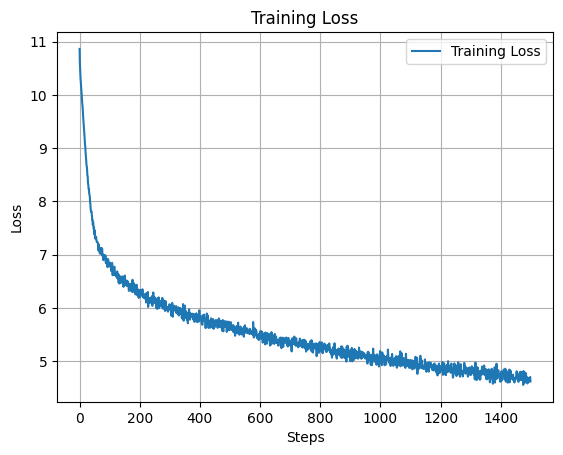

4.620699882507324


In [38]:
# Q1: Plot Training Loss

import matplotlib.pyplot as plt

# TODO:
# - plot loss_history against loss_steps
# - label the axes
# - add a title, grid, and legend

plt.plot(loss_steps, loss_history, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()
plt.show()

print(loss_history[-1])

### Answer 1:

The model begins with an initial loss of around 11, and steeply drops in the 
first 100 epochs. Eventually, the loss decrease slows with small fluctuations
and eventual diminishing returns. Our final loss is around 4.62. There are no
red flags in the loss curve indicating a stable and successfully trained model.

## Q2: What is the validation loss of your model? Is it lower or higher than the final training loss, and why?

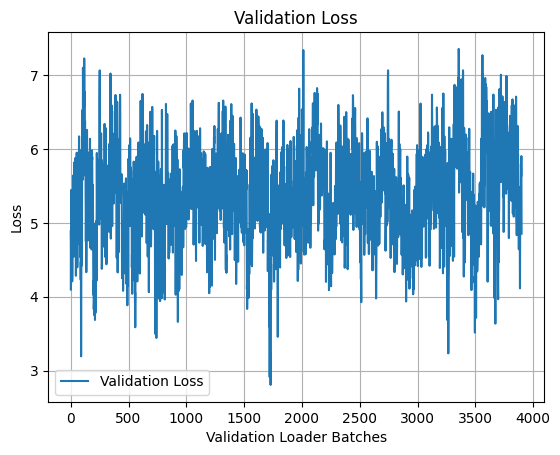

5.381711909355979


In [39]:
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Validation Loader Batches")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.grid(True)
plt.legend()
plt.show()
print(val_loss)

### Answer 2:

The average validation loss on the model is 5.4, which is higher than the final
training loss of 4.6. This is expected as the model is directly optimized on the
training data, whereas the validation set contains unseen data so the model
isn't guaranteed to fit as closely. Because there is a slight gap between
the final training loss and validation loss, we can say the model is slightly
overfitting to the training data.

## Q3: What is the validation perplexity of your model? How does it relate to the validation loss, and what does it indicate about model performance?

In [41]:
# Q3: Compute Validation Perplexity

import math

# TODO: compute validation perplexity from val_loss
val_perplexity = math.exp(val_loss)

print("validation perplexity:", val_perplexity)

validation perplexity: 217.39411607663786


### Answer 3:

The validation perlexity is 217.4, which is the exponential of the validation loss.
Perplexity represents the average number of choices the model is unsure between
at each step, thus a lower perplexity usually indicates a more confident, and thus
better model. This perplexity is reasonably low for the GPT model, indicating
that the model has learned some structure, but could be improved with more training.

## Q4: How do temperature and top-k sampling affect determinism?

Run the `generate` function with different values of temperature and top-k, including extreme settings.

Based on your observations, answer:
- How does temperature affect determinism of the generated text?
- How does top-k affect determinism?
- Under what settings does generation become almost deterministic?
- Under what settings does it become highly random?


In [42]:
# Q4: Experiment with temperature and top-k

temps = [0.2, 0.5, 0.8, 1.0, 1.2, 1.5]
top_ks = [1, 5, 20, 50, 200, None]

prompt = "Hi! How are you doing today?"

start_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device) # TODO: Encode prompt and move to device

for t in temps:
    for k in top_ks:
        out = generate(
            model,
            start_ids,
            max_new_tokens=50,
            temperature=t,
            top_k=k,
        )

        text = tokenizer.decode(out[0].tolist())
        print(f"temp: {t} | top_k: {k} | output: {text}")

temp: 0.2 | top_k: 1 | output: Hi! How are you doing today? , and I 'm going to be a lot of . " 
<|endoftext|> = = = = = = 
<|endoftext|> The first episode was released in the episode of the episode of the episode . The episode was released as a positive review of the
temp: 0.2 | top_k: 5 | output: Hi! How are you doing today? , but they are not to be able to make them . " 
<|endoftext|> = = = = = = 
<|endoftext|> The following year , the first time of the FIA was announced in the first time in the United States , and the FIA was
temp: 0.2 | top_k: 20 | output: Hi! How are you doing today? , and I think I 'm going to be a lot of . " 
<|endoftext|> = = = = = = = 
<|endoftext|> The first episode was a positive review of the episode of the episode of the episode , and the episode of the
temp: 0.2 | top_k: 50 | output: Hi! How are you doing today? , and I can be a good , but I don 't know that you can 't do you 're 're ' . ' 't know you 're 're ' 're ' ' ' ' ' ' ' ' ' ' '
temp: 0.2 | top_k

### Answer 4:

- How does temperature affect determinism of the generated text?

Temperature controls randomness. At low temperature, outputs are very repetitive
and structured, such as having repeated phrases ("the episode"). There is little
variation in the generated sentences, showing high determinism. At medium
temperatures, the sentences are slightly more random, and at high temperatures the
sentences become almost completely random and have random phrases.

- How does top-k affect determinism?

Top-k controls how many tokens are allowed to be sampled. Consequently at `top_k=1`,
all output is identical across any temperature. For small top_k, there are slight
variations in the generated sentences, but still quite structured. For large top_k,
we see much more diverse outputs and variation in word choice.

- Under what settings does generation become almost deterministic?

Generation becomes determinstic for any low temperature and small top_k combination,
and are also deterministic when `top_k=1`.

- Under what settings does it become highly random?

Generation becomes highly random with high temperature or high top_k.